In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, HTML

from notebook_utils import GROUPS_BY_INDICATOR, DS_TO_GROUP_BY_INDICATOR, GROUPS_ORDER_BY_INDICATOR
from notebook_utils import GROUPS, DS_TO_GROUP, GROUPS_ORDER


In [34]:
df = pd.read_csv('neurons_measurements_corr.csv')
print(f"Shape: {df.shape}  ({len(df)} neurons, {len(df.columns)} columns)")
df.dtypes

Shape: (502, 44)  (502 neurons, 44 columns)


neuron_idx                          int64
tau_frames                        float64
tau_ms                            float64
tau_psd_frames                    float64
tau_psd_ms                        float64
pearson_cumsum_raw                float64
pearson_cumsum_calib              float64
spearman_cumsum_raw               float64
spearman_cumsum_calib             float64
pearson_cumsum_raw_psd            float64
pearson_cumsum_calib_psd          float64
spearman_cumsum_raw_psd           float64
spearman_cumsum_calib_psd         float64
gof_tau_pearson_raw               float64
gof_tau_pearson_scaled            float64
gof_tau_spearman_raw              float64
gof_tau_spearman_scaled           float64
gof_tau_psd_pearson_raw           float64
gof_tau_psd_pearson_scaled        float64
gof_tau_psd_spearman_raw          float64
gof_tau_psd_spearman_scaled       float64
pearson_binned_cumsum_raw         float64
spearman_binned_cumsum_raw        float64
pearson_binned_cumsum_raw_psd     

In [35]:
style = """
<style>
  .scrollable-table { max-height: 750px; overflow-y: auto; border: 1px solid #ccc; }
  .df-table { border-collapse: collapse; width: 100%; font-size: 12px; font-family: monospace; }
  .df-table th, .df-table td { border: 1px solid #ddd; padding: 4px 8px; text-align: left; white-space: nowrap; }
  .df-table th { background: #f0f0f0; position: sticky; top: 0; z-index: 1; }
  .df-table tr:nth-child(even) { background: #fafafa; }
</style>
"""

html = f"""
{style}
<div class='scrollable-table'>
  {df.to_html(classes='df-table', border=0)}
</div>
"""

display(HTML(html))


,neuron_idx,tau_frames,tau_ms,tau_psd_frames,tau_psd_ms,pearson_cumsum_raw,pearson_cumsum_calib,spearman_cumsum_raw,spearman_cumsum_calib,pearson_cumsum_raw_psd,pearson_cumsum_calib_psd,spearman_cumsum_raw_psd,spearman_cumsum_calib_psd,gof_tau_pearson_raw,gof_tau_pearson_scaled,gof_tau_spearman_raw,gof_tau_spearman_scaled,gof_tau_psd_pearson_raw,gof_tau_psd_pearson_scaled,gof_tau_psd_spearman_raw,gof_tau_psd_spearman_scaled,pearson_binned_cumsum_raw,spearman_binned_cumsum_raw,pearson_binned_cumsum_raw_psd,spearman_binned_cumsum_raw_psd,pearson_binned_rate_raw,spearman_binned_rate_raw,pearson_binned_rate_raw_psd,spearman_binned_rate_raw_psd,firing_rate_hz,mean_isi_s,cv2,burst_index,global_id,dataset_name,frame_rate,gof_tau_r2,gof_tau_psd_r2,gof_tau_chi2,gof_tau_nmse,gof_tau_psd_chi2,gof_tau_psd_nmse,psd_fit_r2,psd_fit_std_tau
0,0,550.039799,2.750233e+03,48.948037,244.743243,0.998603,0.998603,0.999838,0.999838,0.998634,0.998634,0.999946,0.999946,0.999531,0.999531,0.999266,0.999266,0.999656,0.999656,0.999526,0.999526,0.998598,0.999839,0.998639,0.999946,0.694641,0.565144,0.605867,0.501533,0.763463,1.303450,1.292421,0.547486,0,DS01-OGB1-m-V1,12.175000,NaN,NaN,NaN,NaN,NaN,NaN,0.798573,0.003241
1,1,482.954466,2.414811e+03,27.083588,135.420118,0.995776,0.995776,0.999724,0.999724,0.995702,0.995702,0.999825,0.999825,0.998601,0.998601,0.997201,0.997201,0.999481,0.999481,0.999125,0.999125,0.995708,0.999719,0.995697,0.999823,0.634127,0.469641,0.473032,0.357625,0.793060,1.263130,NaN,0.604096,2,DS01-OGB1-m-V1,11.467000,NaN,NaN,NaN,NaN,NaN,NaN,0.766753,0.001677
2,2,4308.220502,2.154202e+04,23.562661,117.818334,0.948893,0.948893,0.964475,0.964475,0.983543,0.983543,0.997748,0.997748,0.995820,0.995820,0.995829,0.995829,0.999569,0.999569,0.999531,0.999531,0.948964,0.964728,0.983616,0.997801,0.309789,0.271969,0.274356,0.258057,2.767983,0.302705,1.232606,0.654174,3,DS01-OGB1-m-V1,10.926000,NaN,NaN,NaN,NaN,NaN,NaN,0.690532,0.002269
3,3,611.888498,3.059526e+03,26.197844,130.992814,0.999008,0.999008,0.999402,0.999402,0.999141,0.999141,0.999938,0.999938,0.990554,0.990554,0.988660,0.988660,0.999067,0.999067,0.998654,0.998654,0.998976,0.999386,0.999133,0.999943,0.591105,0.526916,0.481463,0.455108,1.268472,0.779363,1.305788,0.556923,4,DS01-OGB1-m-V1,12.175000,NaN,NaN,NaN,NaN,NaN,NaN,0.803980,0.001733
4,4,265.680246,1.328436e+03,25.336750,126.687032,0.996932,0.996932,0.999789,0.999789,0.996778,0.996778,0.999819,0.999819,0.999454,0.999454,0.999305,0.999305,0.999587,0.999587,0.999232,0.999232,0.996878,0.999797,0.996764,0.999821,0.638557,0.449604,0.638029,0.447433,1.074938,0.906078,NaN,0.637119,5,DS01-OGB1-m-V1,11.952000,NaN,NaN,NaN,NaN,NaN,NaN,0.638313,0.002223
5,5,435.574578,2.177904e+03,57.894316,289.475656,0.992950,0.992950,0.999910,0.999910,0.992981,0.992981,0.999977,0.999977,0.988562,0.988562,0.992866,0.992866,0.998300,0.998300,0.998022,0.998022,0.992930,0.999911,0.992963,0.999978,0.317627,0.527585,0.296266,0.487540,2.541013,0.393676,NaN,0.740043,6,DS01-OGB1-m-V1,9.743000,NaN,NaN,NaN,NaN,NaN,NaN,0.810392,0.003942
6,6,654.916030,3.274632e+03,35.944053,179.723123,0.997976,0.997976,0.999341,0.999341,0.997978,0.997978,0.999663,0.999663,0.999564,0.999564,0.999358,0.999358,0.999570,0.999570,0.999340,0.999340,0.998056,0.999415,0.997991,0.999660,0.639141,0.479497,0.514692,0.444793,0.680378,1.476396,1.344342,0.562212,7,DS01-OGB1-m-V1,11.607000,NaN,NaN,NaN,NaN,NaN,NaN,0.800465,0.002391
7,7,464.501392,2.322581e+03,39.955918,199.785973,0.843604,0.843604,0.998941,0.998941,0.846385,0.846385,0.999166,0.999166,0.999526,0.999526,0.998336,0.998336,0.999789,0.999789,0.999379,0.999379,0.843516,0.998966,0.846026,0.999156,0.367224,0.354230,0.645370,0.370359,1.922945,0.520781,NaN,0.834601,8,DS01-OGB1-m-V1,11.607000,NaN,NaN,NaN,NaN,NaN,NaN,0.812486,0.002919
8,8,1433.172367,7.165936e+03,19.168757,95.844783,0.995042,0.995042,0.999490,0.999490,0.995747,0.995747,0.999929,0.999929,0.996827,0.996827,0.996394,0.996394,0.999493,0.999493,0.999370,0.999370,0.994992,0.999458,0.995739,0.9

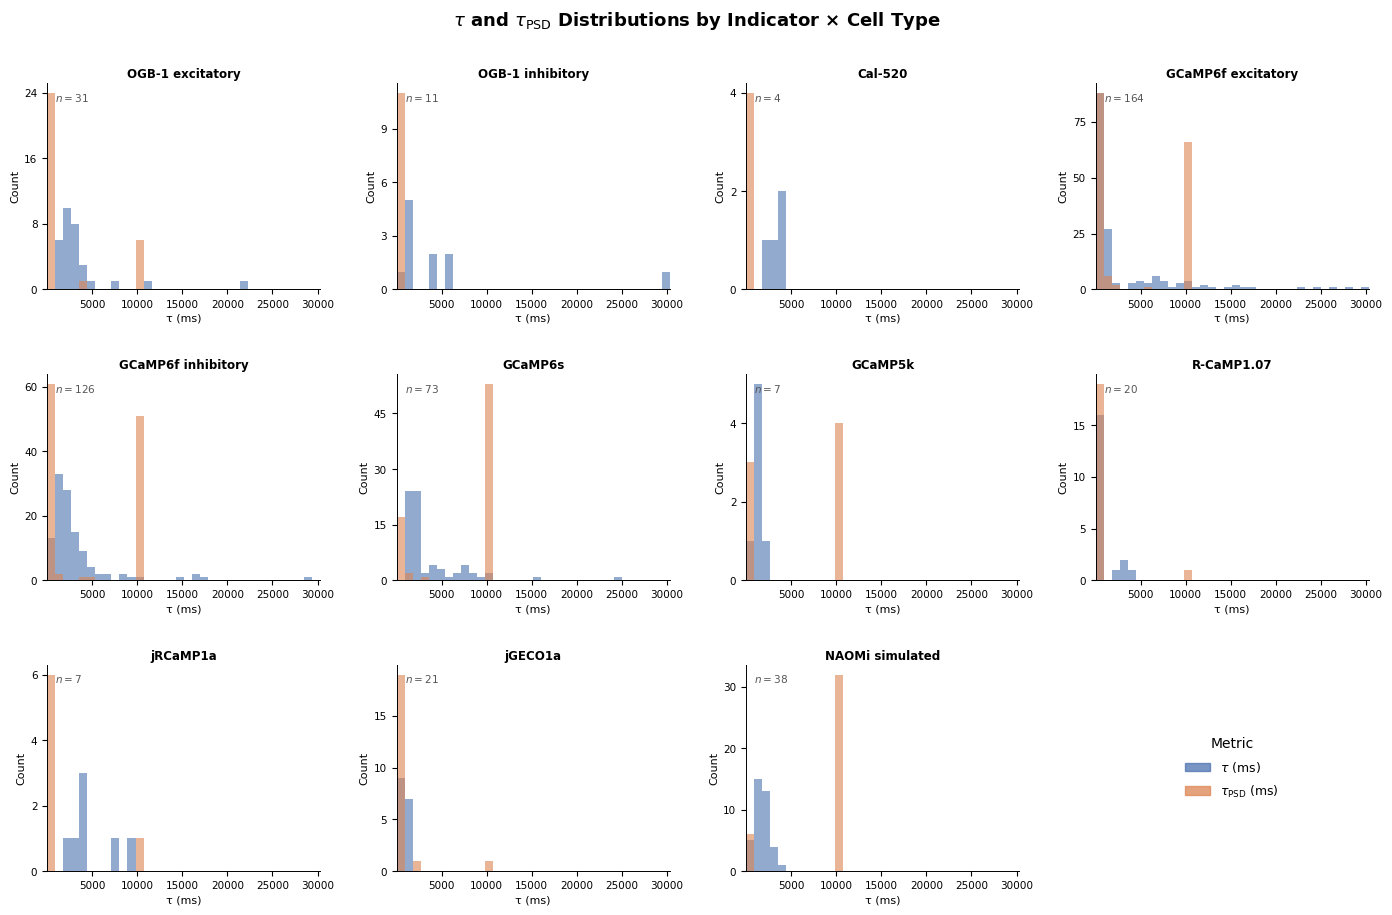

In [36]:
df['group'] = df['dataset_name'].map(DS_TO_GROUP_BY_INDICATOR)
groups_order = GROUPS_ORDER_BY_INDICATOR

tau_cols   = ['tau_ms', 'tau_psd_ms']
tau_labels = [r'$\tau$ (ms)', r'$\tau_\mathrm{PSD}$ (ms)']
tau_colors = ['#4C72B0', '#DD8452']

all_vals = df[tau_cols].values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]
g_min = np.percentile(all_vals, 1)
g_max = np.percentile(all_vals, 99)
bins = np.linspace(g_min, g_max, 35)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes_flat = axes.flatten()

for i, grp in enumerate(groups_order):
    ax = axes_flat[i]
    sub = df[df['group'] == grp]

    for col, color in zip(tau_cols, tau_colors):
        ax.hist(sub[col].dropna(), bins=bins, color=color, alpha=0.60, edgecolor='none')

    ax.set_title(grp, fontsize=8.5, fontweight='bold', pad=4)
    ax.set_xlabel('τ (ms)', labelpad=3)
    ax.set_ylabel('Count', labelpad=3)
    ax.set_xlim(g_min, g_max)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.03, 0.96, f'$n={len(sub)}$', transform=ax.transAxes,
            fontsize=7.5, va='top', ha='left', color='#555555')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=4))

ax_leg = axes_flat[11]
ax_leg.axis('off')
patches = [mpatches.Patch(color=c, alpha=0.75, label=lbl)
           for c, lbl in zip(tau_colors, tau_labels)]
ax_leg.legend(handles=patches, loc='center', fontsize=9,
              frameon=False, title='Metric', title_fontsize=10, labelspacing=0.7)

fig.suptitle(r'$\tau$ and $\tau_\mathrm{PSD}$ Distributions by Indicator × Cell Type',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=2.8, w_pad=2.0)
plt.savefig('tau_by_group.pdf', bbox_inches='tight', dpi=300)
plt.savefig('tau_by_group.png', bbox_inches='tight', dpi=300)
plt.show()


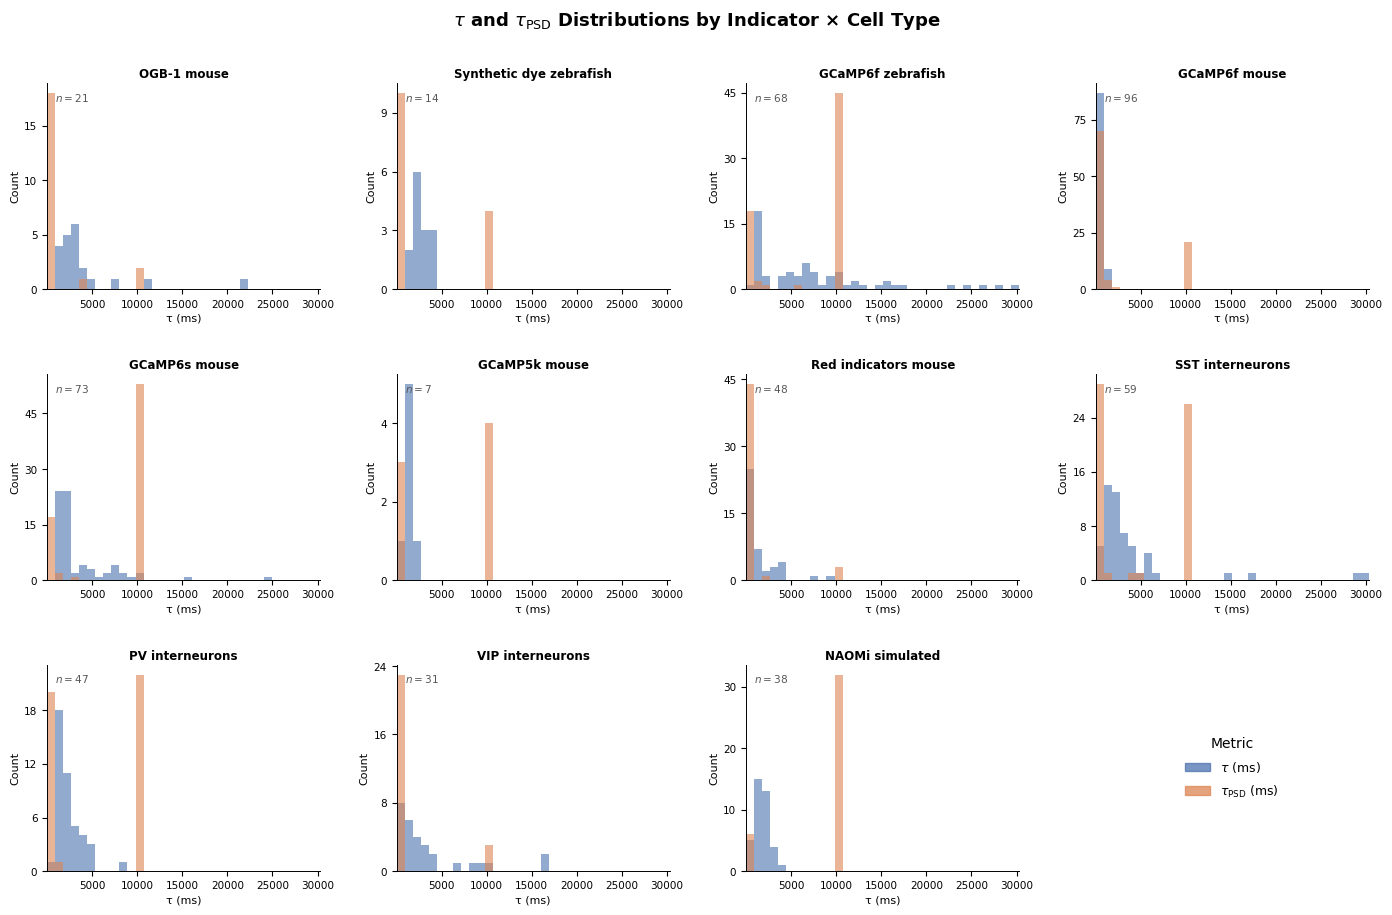

In [37]:
df['group'] = df['dataset_name'].map(DS_TO_GROUP)
groups_order = GROUPS_ORDER



tau_cols   = ['tau_ms', 'tau_psd_ms']
tau_labels = [r'$\tau$ (ms)', r'$\tau_\mathrm{PSD}$ (ms)']
tau_colors = ['#4C72B0', '#DD8452']

all_vals = df[tau_cols].values.flatten()
all_vals = all_vals[~np.isnan(all_vals)]
g_min = np.percentile(all_vals, 1)
g_max = np.percentile(all_vals, 99)
bins = np.linspace(g_min, g_max, 35)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes_flat = axes.flatten()

for i, grp in enumerate(groups_order):
    ax = axes_flat[i]
    sub = df[df['group'] == grp]

    for col, color in zip(tau_cols, tau_colors):
        ax.hist(sub[col].dropna(), bins=bins, color=color, alpha=0.60, edgecolor='none')

    ax.set_title(grp, fontsize=8.5, fontweight='bold', pad=4)
    ax.set_xlabel('τ (ms)', labelpad=3)
    ax.set_ylabel('Count', labelpad=3)
    ax.set_xlim(g_min, g_max)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(0.03, 0.96, f'$n={len(sub)}$', transform=ax.transAxes,
            fontsize=7.5, va='top', ha='left', color='#555555')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=4))

ax_leg = axes_flat[11]
ax_leg.axis('off')
patches = [mpatches.Patch(color=c, alpha=0.75, label=lbl)
           for c, lbl in zip(tau_colors, tau_labels)]
ax_leg.legend(handles=patches, loc='center', fontsize=9,
              frameon=False, title='Metric', title_fontsize=10, labelspacing=0.7)

fig.suptitle(r'$\tau$ and $\tau_\mathrm{PSD}$ Distributions by Indicator × Cell Type',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=2.8, w_pad=2.0)
plt.savefig('tau_by_group.pdf', bbox_inches='tight', dpi=300)
plt.savefig('tau_by_group.png', bbox_inches='tight', dpi=300)
plt.show()


In [39]:
import importlib, notebook_utils
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/mjoudy/Documents/codes/Cascade-Copy/notebook_utils.py'>

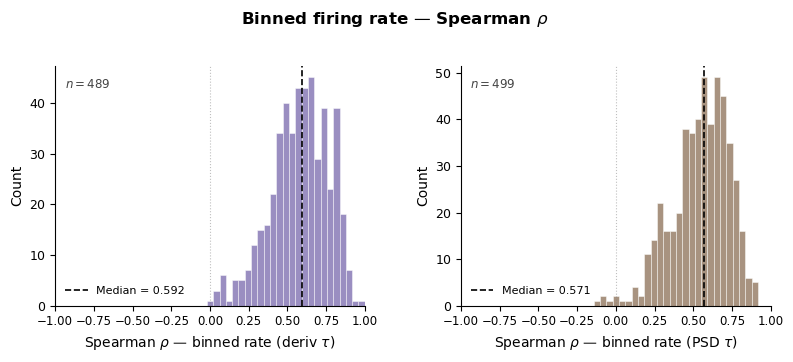

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from notebook_utils import (DS_TO_GROUP_BY_INDICATOR, CORR_COLORS, CORR_RCPARAMS,
                             plot_linear_corr_hist)

df = pd.read_csv('neurons_measurements_corr.csv')
df['group'] = df['dataset_name'].map(DS_TO_GROUP_BY_INDICATOR)

cols   = ['spearman_binned_rate_raw', 'spearman_binned_rate_raw_psd']
labels = [r'Spearman $\rho$ — binned rate (deriv $\tau$)',
          r'Spearman $\rho$ — binned rate (PSD $\tau$)']

plt.rcParams.update(CORR_RCPARAMS)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, col, label, color in zip(axes, cols, labels, CORR_COLORS):
    plot_linear_corr_hist(ax, df[col].dropna(), label, color)
fig.suptitle(r'Binned firing rate — Spearman $\rho$', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3.0)
plt.savefig('figures_outputs/spearman_binned_rate_hist.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures_outputs/spearman_binned_rate_hist.png', bbox_inches='tight', dpi=300)
plt.show()


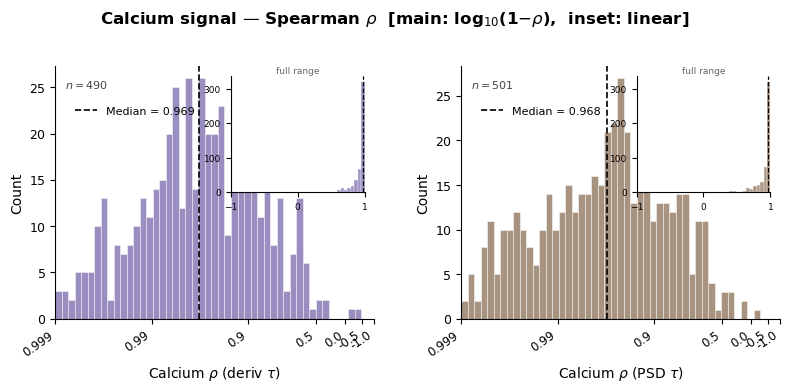

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from notebook_utils import (DS_TO_GROUP_BY_INDICATOR, CORR_COLORS, CORR_RCPARAMS,
                             plot_log_corr_hist)

df = pd.read_csv('neurons_measurements_corr.csv')
df['group'] = df['dataset_name'].map(DS_TO_GROUP_BY_INDICATOR)

cols   = ['gof_tau_spearman_raw', 'gof_tau_psd_spearman_raw']
labels = [r'Calcium $\rho$ (deriv $\tau$)', r'Calcium $\rho$ (PSD $\tau$)']

plt.rcParams.update(CORR_RCPARAMS)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))
for ax, col, label, color in zip(axes, cols, labels, CORR_COLORS):
    plot_log_corr_hist(ax, df[col].dropna(), label, color)
fig.suptitle(r'Calcium signal — Spearman $\rho$  [main: log$_{10}$(1$-\rho$),  inset: linear]',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3.0)
plt.savefig('figures_outputs/spearman_calcium_hist.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures_outputs/spearman_calcium_hist.png', bbox_inches='tight', dpi=300)
plt.show()


1. Which indicator was used
The calcium indicator is the chemical or protein that glows when a neuron fires. Different indicators have very different sensitivity — some produce a big bright flash for a single spike, others barely respond. GCaMP6f is fast and sensitive. GCaMP6s is slower. OGB-1 is a synthetic dye with different noise characteristics. Red indicators (R-CaMP, jRGECO etc.) are generally less sensitive than green ones. If your method works well for GCaMP6f but poorly for red indicators, that tells you something about sensitivity requirements.
2. Mouse vs. zebrafish
This matters mainly because of frame rate. Zebrafish datasets here were recorded at ~7.5 Hz, while mouse datasets go up to 160 Hz. Lower frame rate means coarser time resolution — a continuous spike proxy is harder to reconstruct when you only have a few samples per second.
3. Excitatory vs. inhibitory cell type
Inhibitory neurons (PV, SST, VIP) fire faster and their calcium signals look different — smaller and briefer flashes per spike. PV neurons especially are known to be the hardest case for any spike inference method. If your method struggles on the inhibitory groups, that is expected and well-documented even in this paper.

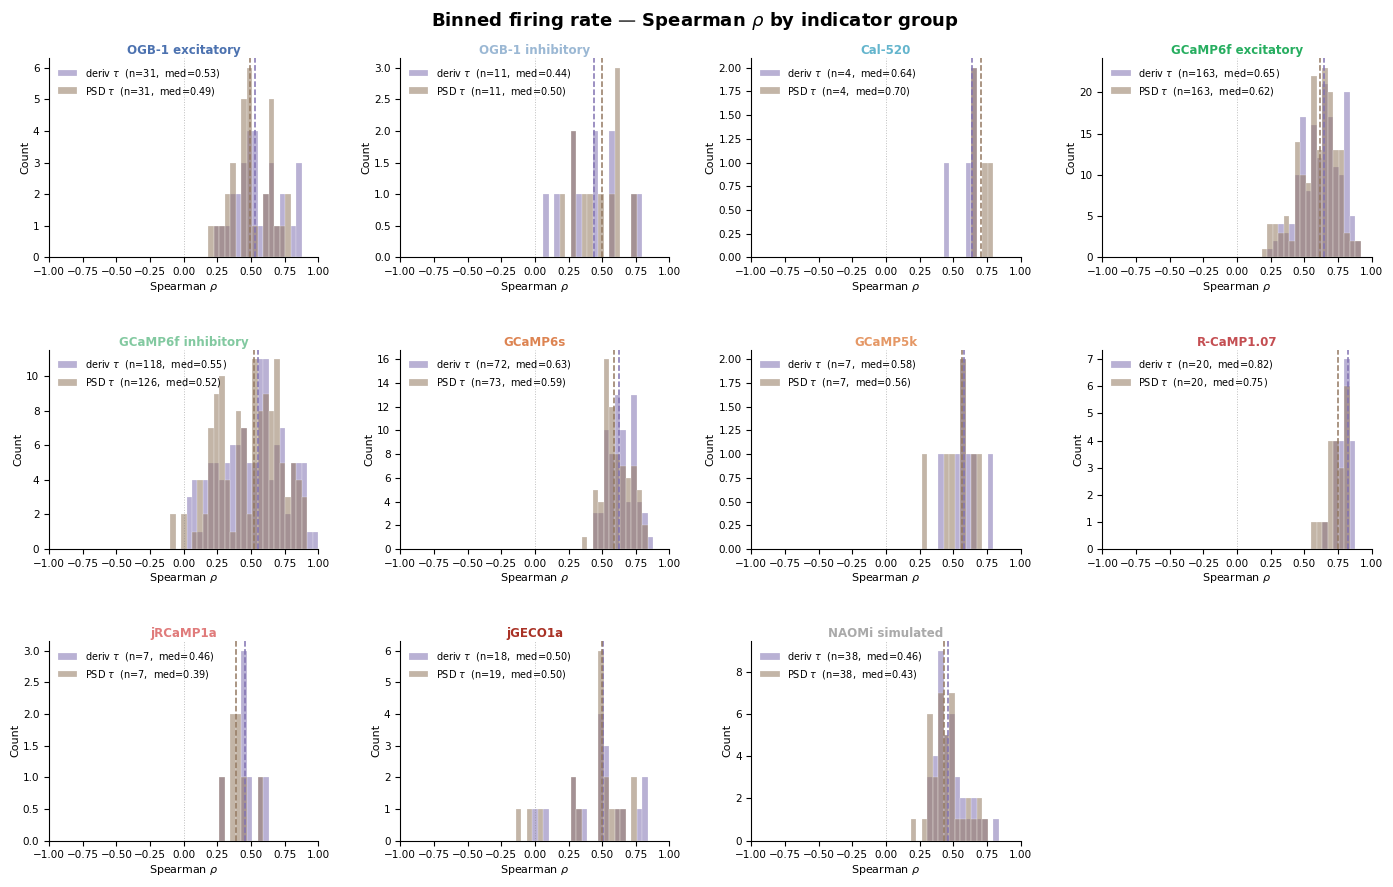

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from notebook_utils import (DS_TO_GROUP_BY_INDICATOR, GROUP_COLORS_BY_INDICATOR,
                             GROUPS_ORDER_BY_INDICATOR, CORR_COLORS, CORR_RCPARAMS,
                             LINEAR_CORR_BINS)

df = pd.read_csv('neurons_measurements_corr.csv')
df['group'] = df['dataset_name'].map(DS_TO_GROUP_BY_INDICATOR)

metric_pairs = [
    ('spearman_binned_rate_raw',     CORR_COLORS[0], r'deriv $\tau$'),
    ('spearman_binned_rate_raw_psd', CORR_COLORS[1], r'PSD $\tau$'),
]

plt.rcParams.update(CORR_RCPARAMS)
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes_flat = axes.flatten()

for i, grp in enumerate(GROUPS_ORDER_BY_INDICATOR):
    ax = axes_flat[i]
    sub = df[df['group'] == grp]

    for col, color, lbl in metric_pairs:
        data = sub[col].dropna()
        if len(data) == 0:
            continue
        median_r = data.median()
        ax.hist(data, bins=LINEAR_CORR_BINS, color=color, alpha=0.55,
                edgecolor='white', linewidth=0.3,
                label=f'{lbl}  (n={len(data)},  med={median_r:.2f})')
        ax.axvline(median_r, color=color, linestyle='--', linewidth=1.1, zorder=3)

    ax.axvline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.set_xlim(-1, 1)
    ax.set_title(grp, fontsize=8.5, fontweight='bold',
                 color=GROUP_COLORS_BY_INDICATOR[grp], pad=3)
    ax.set_xlabel(r'Spearman $\rho$', labelpad=2, fontsize=8)
    ax.set_ylabel('Count', labelpad=2, fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc='upper left')

for j in range(len(GROUPS_ORDER_BY_INDICATOR), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(r'Binned firing rate — Spearman $\rho$ by indicator group',
             fontsize=13, fontweight='bold')
plt.tight_layout(h_pad=3.0, w_pad=2.0)
plt.savefig('figures_outputs/spearman_binned_rate_by_group.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures_outputs/spearman_binned_rate_by_group.png', bbox_inches='tight', dpi=300)
plt.show()


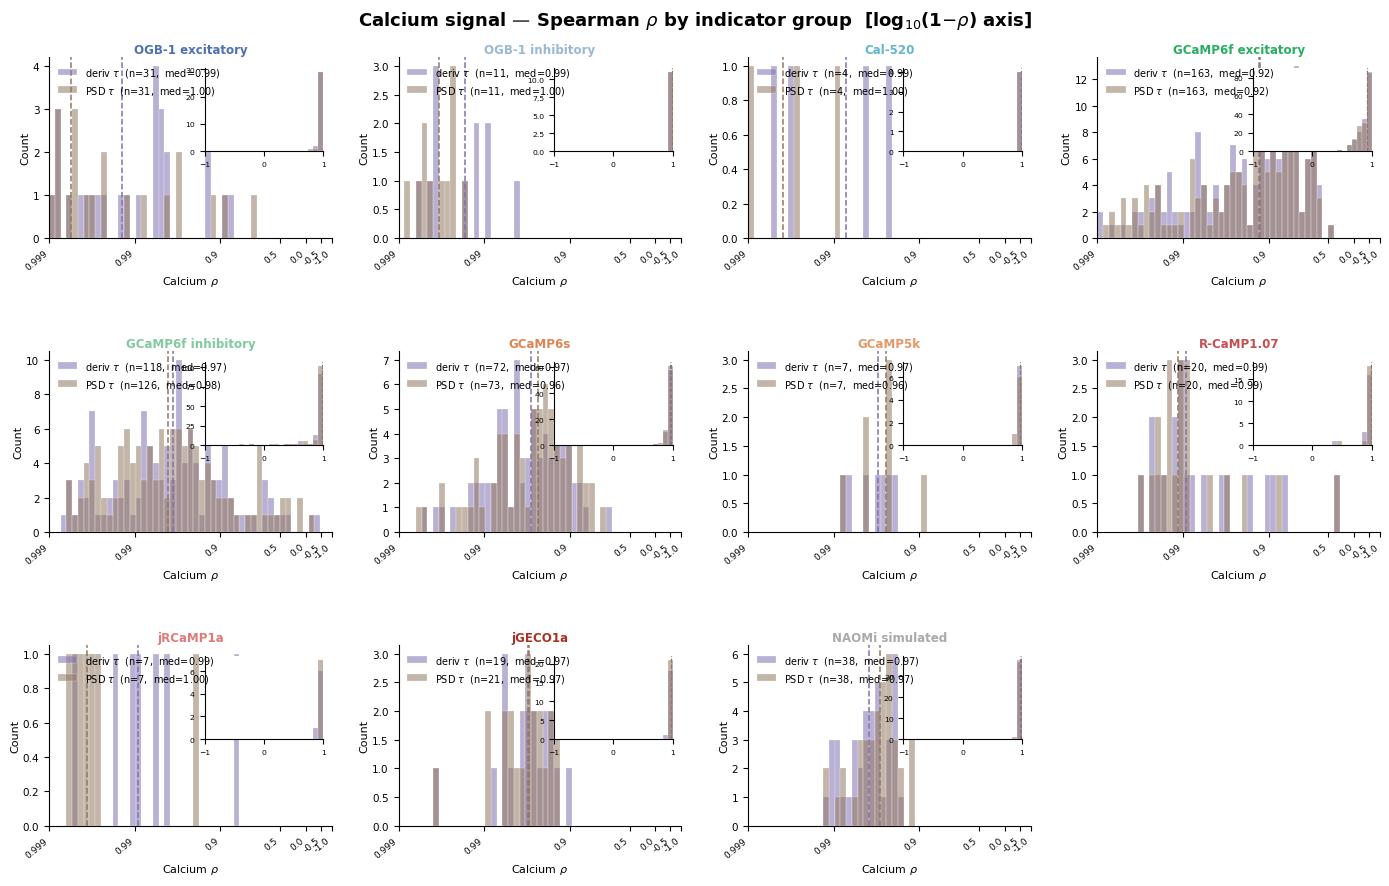

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from notebook_utils import (DS_TO_GROUP_BY_INDICATOR, GROUP_COLORS_BY_INDICATOR,
                             GROUPS_ORDER_BY_INDICATOR, CORR_COLORS, CORR_RCPARAMS,
                             LOG_CORR_BINS, LOG_CORR_XTICKS, LOG_CORR_XLABELS,
                             LOG_CORR_LEFT, LOG_CORR_RIGHT, to_log_corr)

df = pd.read_csv('neurons_measurements_corr.csv')
df['group'] = df['dataset_name'].map(DS_TO_GROUP_BY_INDICATOR)

metric_pairs = [
    ('gof_tau_spearman_raw',     CORR_COLORS[0], r'deriv $\tau$'),
    ('gof_tau_psd_spearman_raw', CORR_COLORS[1], r'PSD $\tau$'),
]

plt.rcParams.update(CORR_RCPARAMS)
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes_flat = axes.flatten()

for i, grp in enumerate(GROUPS_ORDER_BY_INDICATOR):
    ax = axes_flat[i]
    sub = df[df['group'] == grp]

    for col, color, lbl in metric_pairs:
        data = sub[col].dropna()
        if len(data) == 0:
            continue
        median_r = data.median()
        ax.hist(to_log_corr(data), bins=LOG_CORR_BINS, color=color, alpha=0.55,
                edgecolor='white', linewidth=0.3,
                label=f'{lbl}  (n={len(data)},  med={median_r:.2f})')
        ax.axvline(to_log_corr(median_r), color=color, linestyle='--',
                   linewidth=1.1, zorder=3)

    ax.set_xticks(LOG_CORR_XTICKS)
    ax.set_xticklabels(LOG_CORR_XLABELS, rotation=40, ha='right', fontsize=6.5)
    ax.set_xlim(LOG_CORR_LEFT, LOG_CORR_RIGHT)
    ax.set_title(grp, fontsize=8.5, fontweight='bold',
                 color=GROUP_COLORS_BY_INDICATOR[grp], pad=3)
    ax.set_xlabel(r'Calcium $\rho$', labelpad=2, fontsize=8)
    ax.set_ylabel('Count', labelpad=2, fontsize=8)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=7, frameon=False, loc='upper left')

    # inset: linear full range
    ax_in = ax.inset_axes([0.55, 0.48, 0.42, 0.46])
    for col, color, _ in metric_pairs:
        data = sub[col].dropna()
        if len(data) == 0:
            continue
        ax_in.hist(data, bins=np.linspace(-1, 1, 25), color=color,
                   alpha=0.55, edgecolor='white', linewidth=0.2)
        ax_in.axvline(data.median(), color=color, linestyle='--', linewidth=0.8)
    ax_in.set_xlim(-1, 1)
    ax_in.set_xticks([-1, 0, 1])
    ax_in.tick_params(labelsize=5.5)
    ax_in.spines['top'].set_visible(False)
    ax_in.spines['right'].set_visible(False)

for j in range(len(GROUPS_ORDER_BY_INDICATOR), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(r'Calcium signal — Spearman $\rho$ by indicator group  [log$_{10}$(1$-\rho$) axis]',
             fontsize=13, fontweight='bold')
plt.tight_layout(h_pad=3.5, w_pad=2.0)
plt.savefig('figures_outputs/spearman_calcium_by_group.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures_outputs/spearman_calcium_by_group.png', bbox_inches='tight', dpi=300)
plt.show()


High-ρ group : 289 neurons (57.6%)
Low-ρ group  : 213 neurons (42.4%)


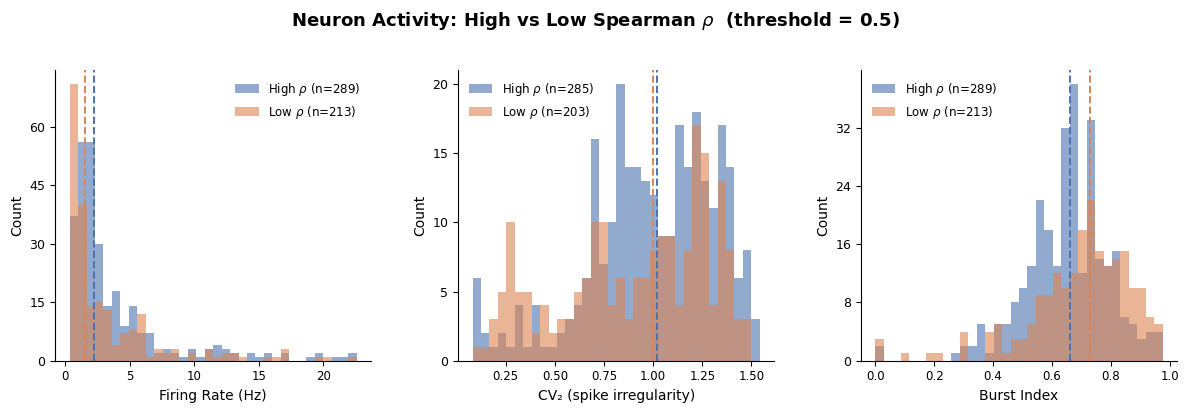

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from notebook_utils import CORR_RCPARAMS

df = pd.read_csv('neurons_measurements_corr.csv')

spearman_cols = [
    'spearman_binned_rate_raw',
    'spearman_binned_rate_raw_psd',
    'gof_tau_spearman_raw',
    'gof_tau_psd_spearman_raw',
]

THRESHOLD = 0.5

low_mask = (df[spearman_cols] < THRESHOLD).any(axis=1)
high = df[~low_mask]
low  = df[low_mask]

print(f"High-ρ group : {len(high)} neurons ({len(high)/len(df)*100:.1f}%)")
print(f"Low-ρ group  : {len(low)} neurons ({len(low)/len(df)*100:.1f}%)")

activity_cols   = ['firing_rate_hz', 'cv2', 'burst_index']
activity_labels = ['Firing Rate (Hz)', 'CV₂ (spike irregularity)', 'Burst Index']

plt.rcParams.update(CORR_RCPARAMS)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col, label in zip(axes, activity_cols, activity_labels):
    h_data = high[col].dropna()
    l_data = low[col].dropna()

    lo = min(h_data.min(), l_data.min())
    hi = max(h_data.quantile(0.99), l_data.quantile(0.99))
    bins = np.linspace(lo, hi, 35)

    ax.hist(h_data, bins=bins, alpha=0.60, color='#4C72B0',
            label=f'High $\\rho$ (n={len(h_data)})')
    ax.hist(l_data, bins=bins, alpha=0.60, color='#DD8452',
            label=f'Low $\\rho$ (n={len(l_data)})')

    ax.axvline(h_data.median(), color='#4C72B0', linestyle='--', linewidth=1.4)
    ax.axvline(l_data.median(), color='#DD8452', linestyle='--', linewidth=1.4)

    ax.set_xlabel(label, labelpad=4)
    ax.set_ylabel('Count', labelpad=4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8.5, frameon=False)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))

fig.suptitle(f'Neuron Activity: High vs Low Spearman $\\rho$  (threshold = {THRESHOLD})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(w_pad=3.0)
plt.savefig('figures_outputs/activity_by_spearman_group.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures_outputs/activity_by_spearman_group.png', bbox_inches='tight', dpi=300)
plt.show()


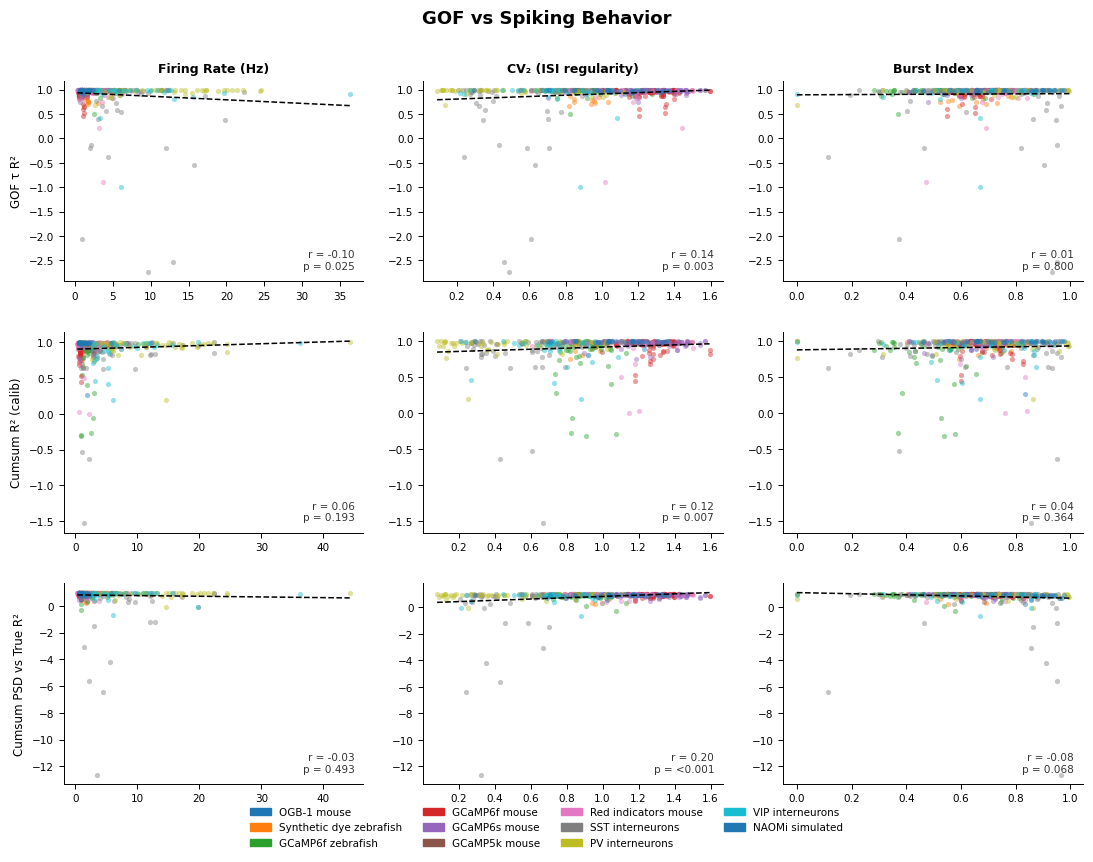

In [13]:
from scipy import stats

# Load measurements (has the extra spiking columns)
df_m = pd.read_csv('neurons_measurements.csv')
df_m['group'] = df_m['dataset_name'].map(ds_to_group)

gof_cols  = ['gof_tau_r2', 'cumsum_r2_calib', 'cumsum_psd_vs_true_r2_calib']
gof_lbls  = ['GOF τ R²', 'Cumsum R² (calib)', 'Cumsum PSD vs True R²']
spk_cols  = ['firing_rate_hz', 'cv2', 'burst_index']
spk_lbls  = ['Firing Rate (Hz)', 'CV₂ (ISI regularity)', 'Burst Index']

import seaborn as sns
palette = dict(zip(groups_order, sns.color_palette("tab10", len(groups_order))))

fig, axes = plt.subplots(len(gof_cols), len(spk_cols), figsize=(11, 8))

for i, (gc, gl) in enumerate(zip(gof_cols, gof_lbls)):
    for j, (sc, sl) in enumerate(zip(spk_cols, spk_lbls)):
        ax = axes[i, j]

        for grp in groups_order:
            sub = df_m[df_m['group'] == grp][[sc, gc]].dropna()
            ax.scatter(sub[sc], sub[gc], color=palette[grp],
                       alpha=0.45, s=14, linewidths=0)

        valid = df_m[[sc, gc]].dropna()
        slope, intercept, r, p, _ = stats.linregress(valid[sc], valid[gc])
        xr = np.linspace(valid[sc].min(), valid[sc].max(), 200)
        ax.plot(xr, slope * xr + intercept, 'k--', lw=1.1, zorder=5)

        pstr = f'{p:.3f}' if p >= 0.001 else '<0.001'
        ax.text(0.97, 0.05, f'r = {r:.2f}\np = {pstr}',
                transform=ax.transAxes, fontsize=7.5,
                ha='right', va='bottom', color='#333333')

        if i == 0: ax.set_title(sl, fontsize=9, fontweight='bold')
        if j == 0: ax.set_ylabel(gl, fontsize=8.5)
        ax.spines[['top','right']].set_visible(False)

handles = [mpatches.Patch(color=palette[g], label=g) for g in groups_order]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=7.5, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('GOF vs Spiking Behavior', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(h_pad=2.5, w_pad=2.0)
plt.show()


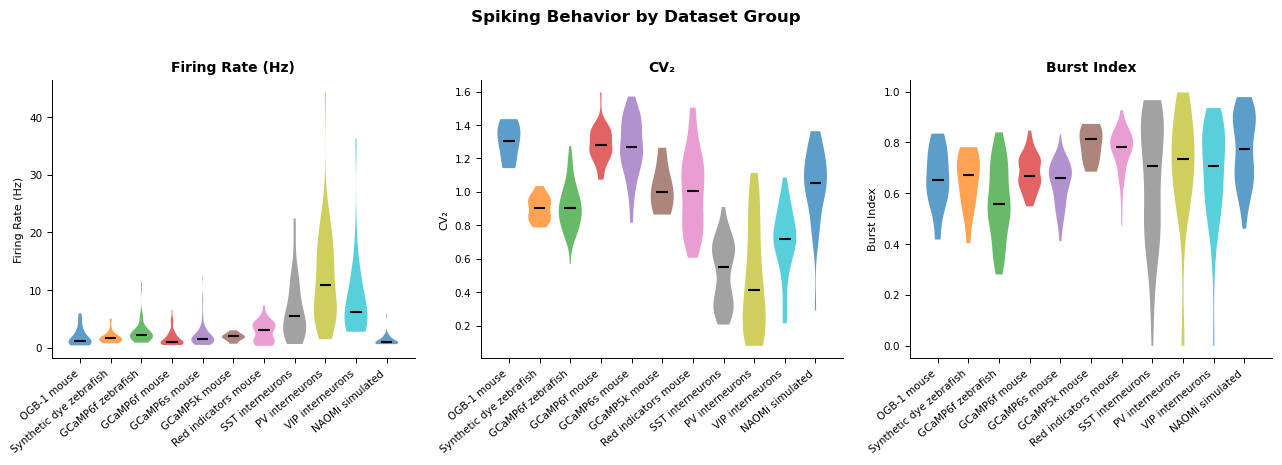

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, col, lbl in zip(axes, spk_cols, spk_lbls):
    data = [df_m[df_m['group'] == g][col].dropna().values for g in groups_order]

    parts = ax.violinplot(data, positions=range(len(groups_order)),
                          showmedians=True, showextrema=False, widths=0.75)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    for pc, grp in zip(parts['bodies'], groups_order):
        pc.set_facecolor(palette[grp])
        pc.set_alpha(0.72)

    ax.set_xticks(range(len(groups_order)))
    ax.set_xticklabels(groups_order, rotation=40, ha='right', fontsize=7.5)
    ax.set_ylabel(lbl)
    ax.set_title(lbl, fontsize=10, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('Spiking Behavior by Dataset Group', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


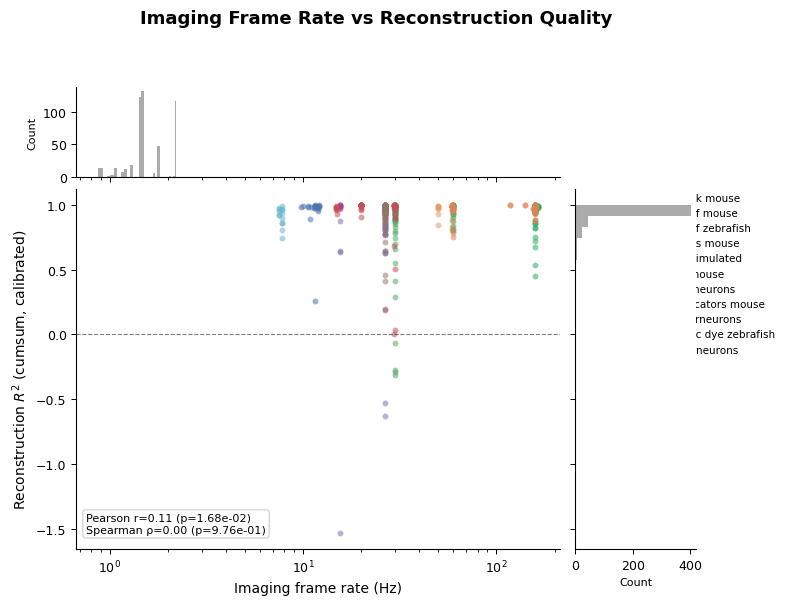

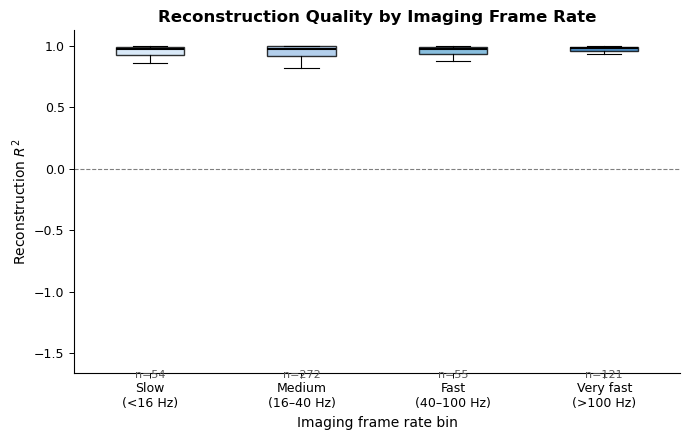

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

df = pd.read_csv('neurons_measurements.csv')

groups = {
    "OGB-1 mouse":             ["DS01-OGB1-m-V1", "DS02-OGB1-2-m-V1"],
    "Synthetic dye zebrafish": ["DS04-OGB1-zf-pDp", "DS05-Cal520-zf-pDp"],
    "GCaMP6f zebrafish":       ["DS06-GCaMP6f-zf-aDp", "DS07-GCaMP6f-zf-dD", "DS08-GCaMP6f-zf-OB"],
    "GCaMP6f mouse":           ["DS09-GCaMP6f-m-V1", "DS10-GCaMP6f-m-V1-neuropil-corrected",
                                "DS11-GCaMP6f-m-V1-neuropil-corrected", "X-DS09-GCaMP6f-m-V1", "X-DS10-GCaMP6f-m-V1"],
    "GCaMP6s mouse":           ["DS12-GCaMP6s-m-V1-neuropil-corrected", "DS13-GCaMP6s-m-V1-neuropil-corrected",
                                "DS14-GCaMP6s-m-V1", "DS15-GCaMP6s-m-V1", "DS16-GCaMP6s-m-V1",
                                "X-DS11-GCaMP6s-m-V1", "X-DS12-GCaMP6s-m-V1"],
    "GCaMP5k mouse":           ["DS17-GCaMP5k-m-V1"],
    "Red indicators mouse":    ["DS18-R-CaMP-m-CA3", "DS19-R-CaMP-m-S1", "DS20-jRCaMP1a-m-V1", "DS21-jGECO1a-m-V1"],
    "SST interneurons":        ["DS22-OGB1-m-SST-V1", "DS25-GCaMP6f-m-SST-V1"],
    "PV interneurons":         ["DS23-OGB1-m-PV-V1", "DS24-GCaMP6f-m-PV-V1", "DS27-GCaMP6f-m-PV-vivo-V1"],
    "VIP interneurons":        ["DS26-GCaMP6f-m-VIP-V1"],
    "NAOMi simulated":         ["X-NAOMi-GCaMP6f-simulated"],
}
ds_to_group = {ds: grp for grp, dss in groups.items() for ds in dss}
df["group"] = df["dataset_name"].map(ds_to_group)

group_colors = {
    "OGB-1 mouse":             "#4C72B0",
    "Synthetic dye zebrafish": "#64B5CD",
    "GCaMP6f zebrafish":       "#55A868",
    "GCaMP6f mouse":           "#27AE60",
    "GCaMP6s mouse":           "#DD8452",
    "GCaMP5k mouse":           "#E59866",
    "Red indicators mouse":    "#C44E52",
    "SST interneurons":        "#8172B2",
    "PV interneurons":         "#AA4499",
    "VIP interneurons":        "#937860",
    "NAOMi simulated":         "#AAAAAA",
}

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.linewidth': 0.8, 'pdf.fonttype': 42, 'ps.fonttype': 42,
})

r2_col = 'cumsum_r2_calib'
fr_col = 'frame_rate'

clean = df[[fr_col, r2_col, 'group']].dropna()

# --- Figure 1: scatter with marginal distributions ---
fig = plt.figure(figsize=(8, 6))
gs  = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

for grp, sub in clean.groupby('group'):
    color = group_colors.get(grp, '#999999')
    ax_main.scatter(sub[fr_col], sub[r2_col],
                    color=color, alpha=0.55, s=18, linewidths=0,
                    label=grp, zorder=2)

ax_main.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax_main.set_xlabel('Imaging frame rate (Hz)', labelpad=4)
ax_main.set_ylabel(r'Reconstruction $R^2$ (cumsum, calibrated)', labelpad=4)
ax_main.set_xscale('log')
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)

log_fr = np.log10(clean[fr_col])
r_p, p_p = pearsonr(log_fr, clean[r2_col])
r_s, p_s = spearmanr(log_fr, clean[r2_col])
ax_main.text(0.02, 0.04,
             f'Pearson r={r_p:.2f} (p={p_p:.2e})\nSpearman ρ={r_s:.2f} (p={p_s:.2e})',
             transform=ax_main.transAxes, fontsize=8, va='bottom',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#cccccc', alpha=0.8))

ax_top.hist(np.log10(clean[fr_col]), bins=30, color='#888888', alpha=0.7, edgecolor='none')
ax_top.set_ylabel('Count', fontsize=8)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_right.hist(clean[r2_col], bins=30, color='#888888', alpha=0.7,
              edgecolor='none', orientation='horizontal')
ax_right.set_xlabel('Count', fontsize=8)
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
plt.setp(ax_right.get_yticklabels(), visible=False)

ax_main.legend(fontsize=7.5, frameon=False, loc='upper left',
               bbox_to_anchor=(1.12, 1.0), borderaxespad=0)

fig.suptitle('Imaging Frame Rate vs Reconstruction Quality',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('frame_rate_vs_r2_scatter.pdf', bbox_inches='tight', dpi=300)
plt.savefig('frame_rate_vs_r2_scatter.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: box plots per frame rate bin ---
# Bins reflect natural slow / medium / fast / very-fast groupings in CASCADE
bins   = [0, 16, 40, 100, np.inf]
labels = ['Slow\n(<16 Hz)', 'Medium\n(16–40 Hz)', 'Fast\n(40–100 Hz)', 'Very fast\n(>100 Hz)']
clean  = clean.copy()
clean['fr_bin'] = pd.cut(clean[fr_col], bins=bins, labels=labels)

fig2, ax2 = plt.subplots(figsize=(7, 4.5))
bin_data = [clean.loc[clean['fr_bin'] == lbl, r2_col].dropna().values for lbl in labels]

bp = ax2.boxplot(bin_data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=1.5),
                 whiskerprops=dict(linewidth=0.8),
                 capprops=dict(linewidth=0.8),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4, markeredgewidth=0))

palette = ['#d0e4f7', '#a0c4e8', '#6aaed6', '#2171b5']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax2.set_xticks(range(1, 5))
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_xlabel('Imaging frame rate bin', labelpad=4)
ax2.set_ylabel(r'Reconstruction $R^2$', labelpad=4)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for i, data in enumerate(bin_data):
    ax2.text(i + 1, ax2.get_ylim()[0] - 0.04,
             f'n={len(data)}', ha='center', fontsize=8, color='#555555')

ax2.set_title('Reconstruction Quality by Imaging Frame Rate',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('r2_by_frame_rate_bin.pdf', bbox_inches='tight', dpi=300)
plt.savefig('r2_by_frame_rate_bin.png', bbox_inches='tight', dpi=300)
plt.show()
